In [10]:
from pathlib import Path
from ase.io import read, write
from ase.build import bulk

# Si.cif holds the conventional (8-atom) cubic cell; pull just the lattice
# constant from it and build the 2-atom primitive diamond cell QE expects.
conventional = read("Si.cif")
a = conventional.cell.cellpar()[0]  # angstrom
atoms = bulk("Si", "diamond", a=a)

In [13]:
pseudo_dir = str(Path(".").resolve())
pseudopotentials = {"Si": "Si.pbe-n-kjpaw_psl.1.0.0.UPF"}

input_data = {
    "control": {
        "calculation": "nscf",
        "prefix": "basic",
        "verbosity": "low",
        "pseudo_dir": pseudo_dir,
        "outdir": ".",
        "tprnfor": True,
        "tstress": True,
    },
    "system": {
        "nat": 2,
        "ntyp": 1,
        "ecutwfc": 50.0,
        "ecutrho": 200.0,
        "input_dft": "pbe",
        "occupations": "tetrahedra",
        "smearing": "mv",
        "degauss": 0.005,
        "nbnd": 8
    },
    "electrons": {
        "conv_thr": 1e-08,
        "mixing_beta": 0.7,
    },
}
kpoints = (35,35,35)  # dense k-point grid for DOS
write("basic_dos.in", atoms, format="espresso-in", input_data=input_data,
      pseudopotentials=pseudopotentials, kpts=kpoints, crystal_coordinates=True)

Run the pw.x and projwfc.x on the files.

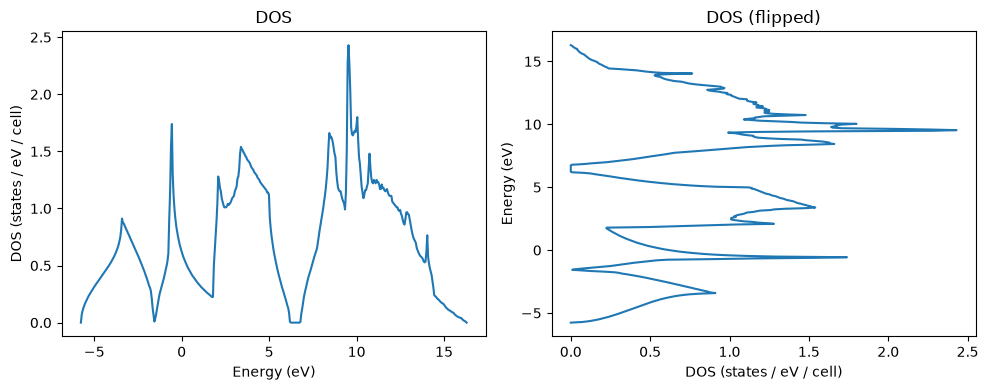

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# projwfc.x already computes the properly BZ-weighted, tetrahedron-integrated
# DOS itself (filpdos='silicon' -> silicon.pdos_tot); read that directly
# rather than re-deriving it from raw eigenvalues in basic_dos_2.out, which
# only gives an unweighted, un-integrated approximation.
E, dos, pdos = np.loadtxt("silicon.pdos_tot", skiprows=1, unpack=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(E, dos)
ax1.set_xlabel("Energy (eV)")
ax1.set_ylabel("DOS (states / eV / cell)")
ax1.set_title("DOS")

ax2.plot(dos, E)
ax2.set_xlabel("DOS (states / eV / cell)")
ax2.set_ylabel("Energy (eV)")
ax2.set_title("DOS (flipped)")

fig.tight_layout()